# Experiment 8: Quasi-Causal Job Title Premiums

**Research question:** Relative to `Data Scientist`, which normalized job-title groups are associated with higher or lower salary under comparable conditions?

**Design summary:** This notebook keeps the same unified dataset and salary parsing pipeline as the earlier experiments, but replaces skill-as-treatment with title-group comparisons. Raw titles are cleaned, mapped into title families, and then optionally split into seniority-aware hybrid groups when there is enough support.

**Why this experiment matters:** Raw title salary gaps can reflect dataset source, seniority, remote status, and overall skill breadth. Matching and fixed effects make the comparisons more comparable before estimating an adjusted title premium.

**Important caution:** This remains observational job-posting data. The estimates are quasi-causal / causal-style under strong assumptions, not proof that changing titles alone will cause the same salary change for an individual.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from helpers import SKILL_PATTERNS, parse_salary
from job_dataset_union import build_unified_jobs_df

In [2]:
BASELINE_TITLE_FAMILY = "Data Scientist"

TOP_N_SKILL_CONTROLS = 8

MIN_TITLE_SUPPORT = 4                  # 30
MIN_MATCHED_TREATMENT_SUPPORT = 2      # 15 

MIN_SALARY_USD = 30_000
MAX_SALARY_USD = 400_000

INVALID_TITLE_VALUES = {"", "-1", "n/a", "na", "none", "null"}
ENTRY_PATTERN = r"\b(?:intern|internship|junior|jr\.?|entry[- ]level|graduate|new grad|associate)\b"
SENIOR_PATTERN = r"\b(?:senior|sr\.?|lead|principal|staff|manager|head|director|vice president|vp\b|chief)\b"

TITLE_FAMILY_PATTERNS = [
    ("VP/Vice President", r"\b(vice president|vp\b|svp\b|avp\b)\b"),
    ("Director", r"\bdirector\b"),
    ("Manager/Head", r"\b(manager|head|chief)\b"),
    ("Intern/Graduate", r"\b(intern|internship|co-op|coop|graduate|college graduate|new grad|grads)\b"),
    ("Consultant", r"\bconsultant\b"),
    ("Architect", r"\barchitect\b"),
    ("Software Engineer", r"\bsoftware engineer\b|\bdata software engineer\b"),
    ("NLP/LLM Specialist", r"\b(nlp engineer|nlp scientist|natural language processing|llm engineer|llm scientist|language model engineer|language model scientist|generative ai engineer|generative ai scientist|prompt engineer)\b"),
    ("MLOps Engineer", r"\b(mlops engineer|machine learning ops engineer|machine learning operations engineer|model deployment engineer|model serving engineer)\b"),
    ("Visualization/Reporting", r"\b(power bi developer|tableau developer|report developer|reporting developer|visualization engineer|data visualization specialist|bi developer|dashboard developer)\b"),
    ("Scientist", r"\b(machine learning scientist|bioinformatics scientist|associate scientist|scientist i\b|scientist ii\b|scientist iii\b|scientist iv\b|sleep medicine scientist)\b"),
    ("Specialist", r"\b(data specialist|analytics specialist|specialist solutions architect)\b"),
    ("Analytics Engineer", r"\b(analytics engineer|decision engineer|data analysis engineer)\b"),
    ("Database/Admin", r"\b(database administrator|database admin|dba|sql dba|database engineer)\b"),
    ("Data Engineer", r"\b(data engineer|data eng|sr data eng|analytics data engineer|data platform engineer|data warehouse engineer|etl engineer|elt engineer|pipeline engineer|etl developer|hadoop developer|data developer)\b"),
    ("ML/AI Engineer", r"\b(machine learning engineer|ml engineer|ai engineer|artificial intelligence engineer|ai/ml engineer|ml/ai engineer|ai / ml engineer|ai-ml engineer|computer vision engineer|deep learning engineer)\b"),
    ("Analyst/BI", r"\b(data analyst|business analyst|business intelligence analyst|bi analyst|market data analyst|analytics analyst|reporting analyst|data science analyst)\b"),
    ("Data Scientist", r"\b(data scientist|decision scientist|applied scientist|research scientist|ai data scientist|analytics scientist|data science)\b"),
]


def normalize_title_text(title):
    if pd.isna(title):
        return pd.NA

    title = str(title).strip().lower()
    title = title.replace("\u2013", "-").replace("\u2014", "-")
    title = title.replace("/", " / ")
    title = re.sub(r"^\s*(remote|hybrid|on[- ]site)\s*[-:]\s*", "", title)
    title = re.sub(r"\s*[-:]\s*(remote|hybrid|on[- ]site)\s*$", "", title)
    title = re.sub(r"\s+", " ", title).strip(" -")

    if not title or title in INVALID_TITLE_VALUES:
        return pd.NA
    return title


def assign_seniority_bucket(title):
    title = str(title).lower()
    entry_mask = bool(re.search(ENTRY_PATTERN, title))
    senior_mask = bool(re.search(SENIOR_PATTERN, title))

    if entry_mask and not senior_mask:
        return "entry_level"
    if senior_mask and not entry_mask:
        return "senior_plus"
    return "mid_level"


def assign_title_family(title):
    title = str(title).lower()
    for family, pattern in TITLE_FAMILY_PATTERNS:
        if re.search(pattern, title):
            return family
    return "Other"


def make_hybrid_title_group(title_family, seniority_bucket):
    if pd.isna(title_family) or title_family == "Other":
        return pd.NA
    if title_family == BASELINE_TITLE_FAMILY and seniority_bucket == "mid_level":
        return BASELINE_TITLE_FAMILY
    if seniority_bucket == "entry_level":
        return f"Entry-level {title_family}"
    if seniority_bucket == "senior_plus":
        return f"Senior+ {title_family}"
    return title_family


def coarsen_skill_count(count):
    count = int(count)
    if count <= 2:
        return "1-2"
    if count <= 4:
        return "3-4"
    if count <= 6:
        return "5-6"
    return "7+"


def make_control_column_name(skill_name):
    safe_name = re.sub(r"[^0-9a-z]+", "_", skill_name.lower()).strip("_")
    return f"ctrl_skill_{safe_name}"


def fit_ols_hc3(y, X):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    xtx_inv = np.linalg.pinv(X.T @ X)
    beta = xtx_inv @ (X.T @ y)
    residuals = y - X @ beta
    leverage = np.sum((X @ xtx_inv) * X, axis=1)

    hc3_scale = (residuals / np.clip(1 - leverage, 1e-8, None)) ** 2
    meat = X.T @ (X * hc3_scale[:, None])
    covariance = xtx_inv @ meat @ xtx_inv

    standard_errors = np.sqrt(np.clip(np.diag(covariance), 0, None))
    z_statistics = beta / np.where(standard_errors == 0, np.nan, standard_errors)
    p_values = 2 * stats.norm.sf(np.abs(z_statistics))
    return beta, standard_errors, p_values


def log_beta_to_percent(beta):
    return (np.exp(beta) - 1) * 100

In [3]:
df = build_unified_jobs_df().copy()

df["salary_usd"] = df["salary_range"].apply(parse_salary)
salary_parse_summary = df.groupby("source_dataset").agg(
    total_jobs=("source_dataset", "size"),
    salary_not_parsed=("salary_usd", lambda s: s.isna().sum()),
)
salary_parse_summary["salary_not_parsed_share_pct"] = (
    salary_parse_summary["salary_not_parsed"] / salary_parse_summary["total_jobs"] * 100
)
df["title_raw"] = df["job_title"].fillna("").astype(str)
df["title_text"] = df["title_raw"].apply(normalize_title_text)
df["location_text"] = df["location"].fillna("").astype(str)
df["title_family"] = df["title_text"].apply(assign_title_family)
df["seniority_bucket"] = df["title_text"].apply(assign_seniority_bucket)

analysis_pool = df[df["salary_usd"].between(MIN_SALARY_USD, MAX_SALARY_USD)].copy()
analysis_pool = analysis_pool[analysis_pool["title_text"].notna()].copy()
analysis_pool = analysis_pool[
    analysis_pool["job_description_skills"].fillna("").astype(str).str.strip() != ""
].copy()

uncovered_title_count = int((analysis_pool["title_family"] == "Other").sum())
uncovered_title_share = uncovered_title_count / len(analysis_pool) * 100 if len(analysis_pool) else 0.0

analysis_df = analysis_pool[analysis_pool["title_family"] != "Other"].copy()

remote_text = analysis_df["location_text"].str.lower()
if "workType" in analysis_df.columns:
    remote_text = remote_text + " " + analysis_df["workType"].fillna("").astype(str).str.lower()
analysis_df["is_remote"] = remote_text.str.contains(r"\bremote\b", regex=True)

skill_flags = pd.DataFrame(
    {
        skill: analysis_df["job_description_skills"].fillna("").astype(str).str.contains(pattern, case=False, regex=True)
        for skill, pattern in SKILL_PATTERNS.items()
    },
    index=analysis_df.index,
)

analysis_df["matched_skill_count"] = skill_flags.sum(axis=1)
analysis_df = analysis_df[analysis_df["matched_skill_count"] > 0].copy()
skill_flags = skill_flags.loc[analysis_df.index].copy()
analysis_df["log_salary"] = np.log(analysis_df["salary_usd"])
analysis_df["skill_count_bin"] = analysis_df["matched_skill_count"].apply(coarsen_skill_count)

top_skill_controls = skill_flags.sum().sort_values(ascending=False).head(TOP_N_SKILL_CONTROLS).index.tolist()
control_rename_map = {skill: make_control_column_name(skill) for skill in top_skill_controls}
analysis_df = analysis_df.join(skill_flags[top_skill_controls].astype(float).rename(columns=control_rename_map))
control_cols = list(control_rename_map.values())

analysis_df["title_group_provisional"] = analysis_df.apply(
    lambda row: make_hybrid_title_group(row["title_family"], row["seniority_bucket"]),
    axis=1,
)

provisional_counts = analysis_df["title_group_provisional"].value_counts()
analysis_df["title_group"] = np.where(
    analysis_df["title_group_provisional"].map(provisional_counts).fillna(0) >= MIN_TITLE_SUPPORT,
    analysis_df["title_group_provisional"],
    analysis_df["title_family"],
)

final_title_counts = analysis_df["title_group"].value_counts()
analysis_df = analysis_df[analysis_df["title_group"].map(final_title_counts) >= MIN_TITLE_SUPPORT].copy()
final_title_counts = analysis_df["title_group"].value_counts()

print(f"Unified rows loaded: {len(df)}")
print(f"Rows after title/salary/skill filters: {len(analysis_df)}")
print(f"Median salary in analysis sample: ${analysis_df['salary_usd'].median():,.0f}")
print(f"Baseline Data Scientist family support: {(analysis_df['title_family'] == BASELINE_TITLE_FAMILY).sum()}")
print(f"Titles not covered by any family before dropping Other: {uncovered_title_count} ({uncovered_title_share:.1f}%)")
print()

print("Source breakdown:")
print(analysis_df["source_dataset"].value_counts().to_string())
print()

print("Salary parse failures by source (full unified data):")
print(
    salary_parse_summary.to_string(
        formatters={"salary_not_parsed_share_pct": lambda value: f"{value:.1f}%"}
    )
)
print()

print("Title-group breakdown (top 15):")
print(final_title_counts.head(15).to_string())
print()

print("Top skill controls used only for residual adjustment:")
print(pd.Series(top_skill_controls, index=range(1, len(top_skill_controls) + 1)).to_string())

Unified rows loaded: 7394
Rows after title/salary/skill filters: 1516
Median salary in analysis sample: $126,000
Baseline Data Scientist family support: 1132
Titles not covered by any family before dropping Other: 66 (2.8%)

Source breakdown:
source_dataset
data_science_job_posts_2025    691
glassdoor_2023                 539
our_own_dataset                286

Salary parse failures by source (full unified data):
                             total_jobs  salary_not_parsed salary_not_parsed_share_pct
source_dataset                                                                        
data_science_job_posts_2025         944                  0                        0.0%
glassdoor_2023                     1500                375                       25.0%
our_own_dataset                    4950               4433                       89.6%

Title-group breakdown (top 15):
title_group
Data Scientist                961
Senior+ Data Scientist        156
ML/AI Engineer                 76
D

In [4]:
final_title_counts.head(40)

title_group
Data Scientist                 961
Senior+ Data Scientist         156
ML/AI Engineer                  76
Data Engineer                   67
Analyst/BI                      57
Senior+ Director                27
Senior+ Data Engineer           23
Senior+ Manager/Head            17
Senior+ VP/Vice President       17
Entry-level Data Scientist      15
Senior+ Analyst/BI              14
Scientist                       13
Software Engineer               13
Architect                       12
Analytics Engineer              12
Senior+ ML/AI Engineer          11
Entry-level Intern/Graduate      8
Visualization/Reporting          8
Senior+ Software Engineer        5
Consultant                       4
Name: count, dtype: int64

## Matched Fixed-Effects Title Comparisons

For each eligible title group outside the `Data Scientist` family, we compare that group against a `Data Scientist` baseline inside matched strata defined by:

- `source_dataset`
- `is_remote`
- `seniority_bucket`
- coarsened `matched_skill_count`

Only strata that contain both the treatment title group and the `Data Scientist` baseline are kept. Inside that matched sample, we run OLS on `log_salary` with:

- a treatment indicator for the focal title group
- stratum fixed effects
- continuous `matched_skill_count`
- the top 8 most-supported skill flags as controls only

This is stronger than a raw correlation, but it still relies on observational assumptions and should be described as quasi-causal or causal-style, not fully causal.

In [5]:
results = []

eligible_title_groups = []
for title_group, support in final_title_counts.items():
    family_mode = analysis_df.loc[analysis_df["title_group"] == title_group, "title_family"].mode()
    if family_mode.empty:
        continue
    if family_mode.iat[0] == BASELINE_TITLE_FAMILY:
        continue
    eligible_title_groups.append(title_group)

for title_group in eligible_title_groups:
    target_mask = analysis_df["title_group"] == title_group
    raw_support = int(target_mask.sum())
    target_family = analysis_df.loc[target_mask, "title_family"].mode().iat[0]

    compare_df = analysis_df.loc[target_mask | (analysis_df["title_family"] == BASELINE_TITLE_FAMILY)].copy()
    compare_df["is_treatment"] = (compare_df["title_group"] == title_group).astype(float)
    compare_df["stratum_key"] = (
        compare_df["source_dataset"].astype(str)
        + " | remote=" + compare_df["is_remote"].astype(int).astype(str)
        + " | seniority=" + compare_df["seniority_bucket"].astype(str)
        + " | skill_bin=" + compare_df["skill_count_bin"].astype(str)
    )

    stratum_class_counts = compare_df.groupby("stratum_key")["is_treatment"].nunique()
    valid_strata = stratum_class_counts[stratum_class_counts == 2].index
    matched_df = compare_df[compare_df["stratum_key"].isin(valid_strata)].copy()

    # TODO: check that 
    # matched_support = 5
    matched_support = int(matched_df["is_treatment"].sum()) / 10

    baseline_matched_support = int((matched_df["is_treatment"] == 0).sum())
    matched_strata = int(matched_df["stratum_key"].nunique())

    if matched_support < MIN_MATCHED_TREATMENT_SUPPORT:
        continue
    if baseline_matched_support < MIN_MATCHED_TREATMENT_SUPPORT:
        continue

    X = pd.DataFrame(
        {
            "const": 1.0,
            "is_treatment": matched_df["is_treatment"].astype(float),
            "matched_skill_count": matched_df["matched_skill_count"].astype(float),
        },
        index=matched_df.index,
    )
    X = pd.concat(
        [
            X,
            matched_df[control_cols].astype(float),
            pd.get_dummies(matched_df["stratum_key"], prefix="stratum", drop_first=True, dtype=float),
        ],
        axis=1,
    )

    beta, standard_errors, p_values = fit_ols_hc3(matched_df["log_salary"].to_numpy(), X.to_numpy())
    coef_idx = X.columns.get_loc("is_treatment")
    title_beta = beta[coef_idx]
    premium_pct = log_beta_to_percent(title_beta)

    mean_treatment_salary = matched_df.loc[matched_df["is_treatment"] == 1, "salary_usd"].mean()
    mean_baseline_salary = matched_df.loc[matched_df["is_treatment"] == 0, "salary_usd"].mean()
    matched_median_salary = matched_df["salary_usd"].median()

    results.append(
        {
            "title_group": title_group,
            "title_family": target_family,
            "raw_support": raw_support,
            "share_pct": raw_support / len(analysis_df) * 100,
            "matched_support": matched_support,
            "baseline_matched_support": baseline_matched_support,
            "matched_strata": matched_strata,
            "premium_pct": premium_pct,
            "approx_salary_delta_usd": matched_median_salary * (premium_pct / 100),
            "coef_log_salary": title_beta,
            "std_error": standard_errors[coef_idx],
            "p_value": p_values[coef_idx],
            "mean_treatment_salary": mean_treatment_salary,
            "mean_baseline_salary": mean_baseline_salary,
            "naive_salary_gap_usd": mean_treatment_salary - mean_baseline_salary,
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["premium_pct", "matched_support"],
    ascending=[False, False],
).reset_index(drop=True)

results_df["significant_5pct"] = results_df["p_value"] < 0.05     # 0.05

print("Adjusted title ranking relative to the Data Scientist baseline:")
if results_df.empty:
    print("No eligible title groups produced a matched estimate under the current support thresholds.")
else:
    print(
        results_df[
            [
                "title_group",
                "title_family",
                "raw_support",
                "matched_support",
                "matched_strata",
                "premium_pct",
                "approx_salary_delta_usd",
                "p_value",
            ]
        ].head(15).to_string(index=False)
    )

Adjusted title ranking relative to the Data Scientist baseline:
   title_group   title_family  raw_support  matched_support  matched_strata  premium_pct  approx_salary_delta_usd      p_value
ML/AI Engineer ML/AI Engineer           76              7.6              11    10.553112             13719.045724 1.290015e-01
 Data Engineer  Data Engineer           67              6.5              11    -5.829503             -7345.174229 3.013714e-01
    Analyst/BI     Analyst/BI           57              5.7               8   -35.872168            -39459.384789 2.325336e-13


In [6]:
positive_titles = results_df[(results_df["premium_pct"] > 0) & (results_df["significant_5pct"])] if not results_df.empty else pd.DataFrame()
negative_titles = results_df[(results_df["premium_pct"] < 0) & (results_df["significant_5pct"])] if not results_df.empty else pd.DataFrame()

print("Top positive quasi-causal title premiums vs Data Scientist:")
if positive_titles.empty:
    print("No title groups have a positive and statistically significant premium at the 5% level.")
else:
    print(
        positive_titles[
            [
                "title_group",
                "raw_support",
                "matched_support",
                "premium_pct",
                "approx_salary_delta_usd",
                "p_value",
            ]
        ].head(10).to_string(index=False)
    )

print("\nTop negative quasi-causal title premiums vs Data Scientist:")
if negative_titles.empty:
    print("No title groups have a negative and statistically significant premium at the 5% level.")
else:
    print(
        negative_titles[
            [
                "title_group",
                "raw_support",
                "matched_support",
                "premium_pct",
                "approx_salary_delta_usd",
                "p_value",
            ]
        ].head(10).to_string(index=False)
    )

print("\nCompact ranking table:")
if results_df.empty:
    print("No results to display.")
else:
    print(
        results_df[
            [
                "title_group",
                "title_family",
                "raw_support",
                "matched_support",
                "premium_pct",
                "p_value",
                "significant_5pct",
            ]
        ].head(20).to_string(index=False)
    )

Top positive quasi-causal title premiums vs Data Scientist:
No title groups have a positive and statistically significant premium at the 5% level.

Top negative quasi-causal title premiums vs Data Scientist:
title_group  raw_support  matched_support  premium_pct  approx_salary_delta_usd      p_value
 Analyst/BI           57              5.7   -35.872168            -39459.384789 2.325336e-13

Compact ranking table:
   title_group   title_family  raw_support  matched_support  premium_pct      p_value  significant_5pct
ML/AI Engineer ML/AI Engineer           76              7.6    10.553112 1.290015e-01             False
 Data Engineer  Data Engineer           67              6.5    -5.829503 3.013714e-01             False
    Analyst/BI     Analyst/BI           57              5.7   -35.872168 2.325336e-13              True


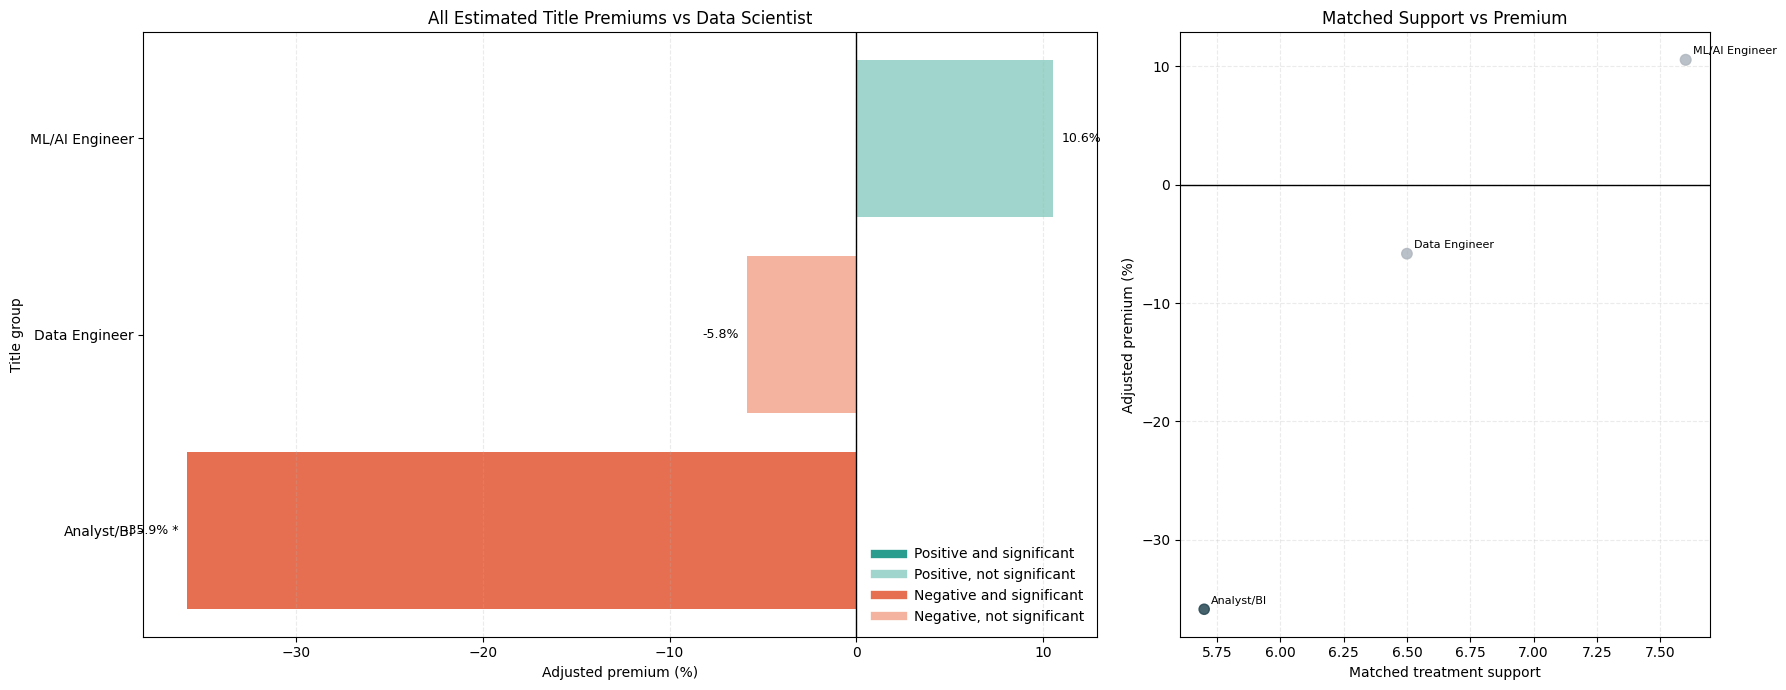

In [7]:
if results_df.empty:
    print("No title-premium estimates available to plot.")
else:
    plot_df = results_df.sort_values("premium_pct").copy()
    plot_df["bar_color"] = np.select(
        [
            (plot_df["premium_pct"] >= 0) & plot_df["significant_5pct"],
            (plot_df["premium_pct"] >= 0) & ~plot_df["significant_5pct"],
            (plot_df["premium_pct"] < 0) & plot_df["significant_5pct"],
        ],
        ["#2a9d8f", "#9fd5cc", "#e76f51"],
        default="#f3b39f",
    )
    plot_df["label_text"] = plot_df.apply(
        lambda row: f"{row['premium_pct']:.1f}%" + (" *" if row["significant_5pct"] else ""),
        axis=1,
    )

    fig_height = max(7, 0.48 * len(plot_df) + 2)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, fig_height),
        gridspec_kw={"width_ratios": [1.8, 1.0]},
    )

    axes[0].barh(plot_df["title_group"], plot_df["premium_pct"], color=plot_df["bar_color"])
    for idx, row in enumerate(plot_df.itertuples(index=False)):
        text_offset = 0.45 if row.premium_pct >= 0 else -0.45
        ha = "left" if row.premium_pct >= 0 else "right"
        axes[0].text(row.premium_pct + text_offset, idx, row.label_text, va="center", ha=ha, fontsize=9)
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].grid(axis="x", linestyle="--", alpha=0.25)
    axes[0].set_title("All Estimated Title Premiums vs Data Scientist")
    axes[0].set_xlabel("Adjusted premium (%)")
    axes[0].set_ylabel("Title group")

    scatter_colors = np.where(plot_df["significant_5pct"], "#264653", "#b0b7bf")
    scatter_sizes = 40 + plot_df["matched_support"].to_numpy() * 2.5
    axes[1].scatter(
        plot_df["matched_support"],
        plot_df["premium_pct"],
        s=scatter_sizes,
        c=scatter_colors,
        alpha=0.85,
    )
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].grid(axis="both", linestyle="--", alpha=0.25)
    axes[1].set_title("Matched Support vs Premium")
    axes[1].set_xlabel("Matched treatment support")
    axes[1].set_ylabel("Adjusted premium (%)")

    label_candidates = pd.concat(
        [plot_df.head(min(4, len(plot_df))), plot_df.tail(min(4, len(plot_df)))],
        axis=0,
    ).drop_duplicates(subset=["title_group"])
    for _, row in label_candidates.iterrows():
        axes[1].annotate(
            row["title_group"],
            (row["matched_support"], row["premium_pct"]),
            fontsize=8,
            xytext=(5, 4),
            textcoords="offset points",
        )

    legend_lines = [
        plt.Line2D([0], [0], color="#2a9d8f", lw=6, label="Positive and significant"),
        plt.Line2D([0], [0], color="#9fd5cc", lw=6, label="Positive, not significant"),
        plt.Line2D([0], [0], color="#e76f51", lw=6, label="Negative and significant"),
        plt.Line2D([0], [0], color="#f3b39f", lw=6, label="Negative, not significant"),
    ]
    axes[0].legend(handles=legend_lines, loc="lower right", frameon=False)

    plt.tight_layout()
    plt.show()

## Outputs for report

The block below prints the same 4 report-style items as the earlier experiments, but now based on the title-premium design used in `experiment_8`.

Report-ready summary:
* (1) Variable / Inputs: Average salary. We compare normalized title groups against Data Scientist under similar job and skill conditions.
* (2) Model: Matched fixed-effects OLS (Ordinary Least Squares) estimates title differences, controlling for source, remote status, seniority, skill count, and key skills.
* (3) Finding Statement: Analyst/BI shows a significant negative salary effect, while no title group has a significant positive premium
* (4) Limitation or Extension: Title may reflect role scope and seniority, so results are quasi-causal and not proof of causation.

## Validation checks

In [8]:
assert (analysis_df["title_family"] == BASELINE_TITLE_FAMILY).any(), "Baseline Data Scientist family is missing from the analysis sample."
assert not analysis_df["title_text"].isin(INVALID_TITLE_VALUES).any(), "Placeholder titles survived title cleaning."
if not results_df.empty:
    assert results_df["raw_support"].ge(MIN_TITLE_SUPPORT).all(), "A reported title group fell below MIN_TITLE_SUPPORT."
    assert results_df["matched_strata"].ge(1).all(), "Each estimate must retain at least one matched stratum."

print("Normalization examples:")
examples = analysis_df.loc[
    analysis_df["title_raw"].str.contains(
        r"data scientist|data engineer|business analyst|machine learning engineer|remote - data scientist",
        case=False,
        na=False,
        regex=True,
    ),
    ["title_raw", "title_text", "title_family", "seniority_bucket", "title_group"],
].drop_duplicates().head(15)
print(examples.to_string(index=False))
print()

print("Sanity-check family counts:")
for family in ["Data Engineer", "ML/AI Engineer", "Analyst/BI", "Data Scientist"]:
    print(f"{family}: {(analysis_df['title_family'] == family).sum()}")
print()

print("Validation summary:")
print(f"- Invalid placeholders removed: {not analysis_df['title_text'].isin(INVALID_TITLE_VALUES).any()}")
print(f"- Uncovered titles before dropping Other: {uncovered_title_count} ({uncovered_title_share:.1f}%)")
print(f"- Eligible title groups reported: {len(results_df)}")
print(f"- Minimum raw support enforced: {MIN_TITLE_SUPPORT}")
print(f"- Baseline family: {BASELINE_TITLE_FAMILY}")
print("- Matching dimensions: source_dataset, is_remote, seniority_bucket, skill_count_bin")

Normalization examples:
                                                               title_raw                                                               title_text    title_family seniority_bucket                 title_group
                               2024 University Graduate - Data Scientist                                2024 university graduate - data scientist Intern/Graduate      entry_level Entry-level Intern/Graduate
                                       Data Scientist – Entry Level 2024                                        data scientist - entry level 2024  Data Scientist      entry_level  Entry-level Data Scientist
                                                        Data Scientist 2                                                         data scientist 2  Data Scientist        mid_level              Data Scientist
                                                      Data Scientist (C)                                                       data scientist (c)  D